In [318]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

In [319]:
# import sp500 data 

sp500 = yf.Ticker("^GSPC")
sp500 = sp500.history(period="max")
sp500.columns = sp500.columns.get_level_values(0)


In [320]:
sp500.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


<Axes: xlabel='Date', ylabel='Close'>

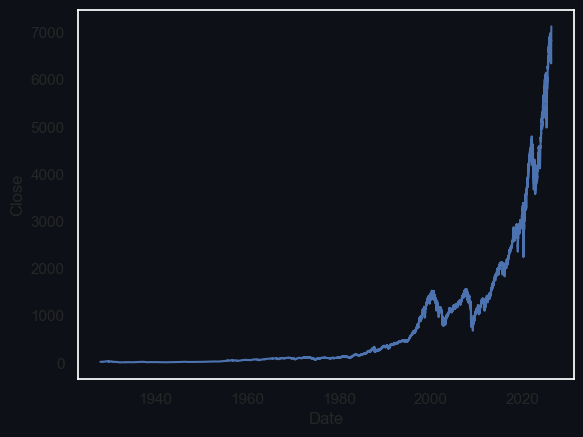

In [321]:
sns.lineplot(data=sp500, x=sp500.index, y=sp500["Close"])

## Data preprocessing

In [322]:
# remove unnecessary colums
sp500 = sp500.drop(columns={"Dividends", "Stock Splits"})
sp500

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...
2026-04-13 00:00:00-04:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000
2026-04-14 00:00:00-04:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000
2026-04-15 00:00:00-04:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000


In [323]:
# Remove Time and Timezone (Keep as Datetime)
sp500.index = sp500.index.tz_localize(None).floor('D')

In [324]:
# take the "Close" price of the next day and pulls it back to the current row
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [325]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-04-13,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,6967.379883
2026-04-14,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195
2026-04-15,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785


In [326]:
# Add target column
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [327]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-04-13,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,6967.379883,1
2026-04-14,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195,1
2026-04-15,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785,1


In [328]:
# remove old unusefull data (less thean "1990-01-01")
sp500 = sp500.loc["1990-01-01":].copy()

In [329]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-04-13,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,6967.379883,1
2026-04-14,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195,1
2026-04-15,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785,1


## Build the model

#### Notes and explainations

 
min_samples_split=100 ==> This is a tool to prevent overfitting It tells a tree that it cannot split a node further
unless there are at least 100 data points in that node



n_estimators=100 ==> This tells the model to build 100 individual decision trees. Generally, more trees increase
the model's performance but make it slower to train


 
random_state=1 ==> This ensures reproducibility


In [330]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=2)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]

model.fit(train[predictors], train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [331]:
# Model Evaluation
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix

preds = model.predict(test[predictors])

In [332]:
preds

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0])

In [333]:
preds = pd.DataFrame(preds, index=test.index)
preds = preds.rename(columns={0:"Model Predection"})

In [334]:
preds

,Model Predection
Date,
2025-11-21,1
2025-11-24,1
2025-11-25,1
2025-11-26,1
2025-11-28,0
...,...
2026-04-13,1
2026-04-14,0
2026-04-15,0


In [335]:
combined = pd.concat([test["Target"], preds], axis=1)
combined

,Target,Model Predection
Date,,
2025-11-21,1,1
2025-11-24,1,1
2025-11-25,1,1
2025-11-26,1,1
2025-11-28,0,0
...,...,...
2026-04-13,1,1
2026-04-14,1,0
2026-04-15,1,0


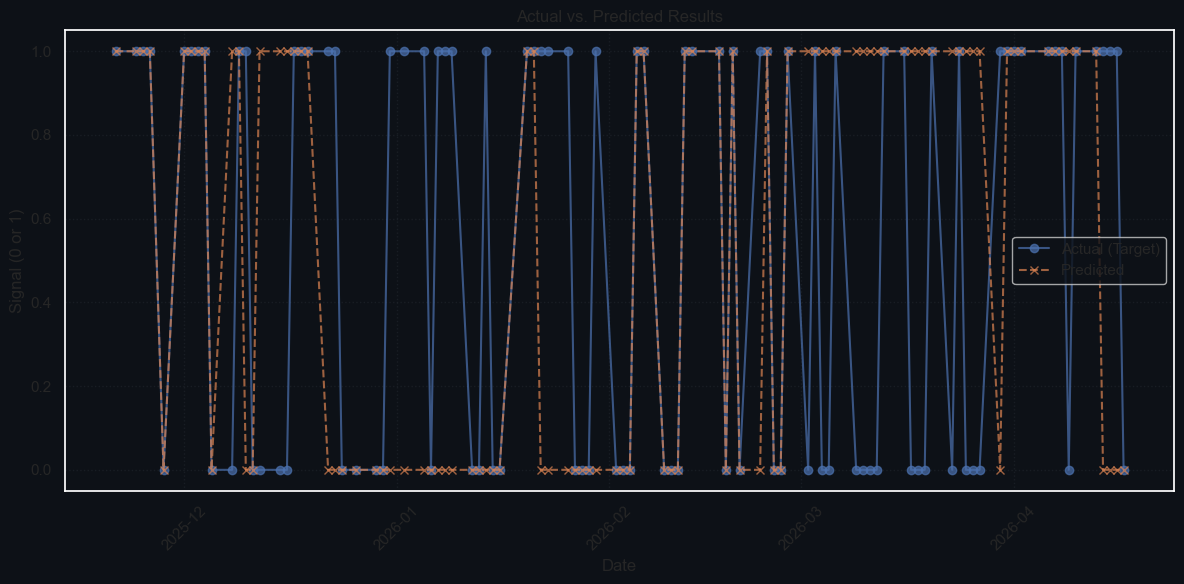

In [336]:
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'predictions'
plt.figure(figsize=(12, 6))

# Plotting both columns
plt.plot(combined.index, combined['Target'], label='Actual (Target)', marker='o', linestyle='-', alpha=0.7)
plt.plot(combined.index, combined['Model Predection'], label='Predicted', marker='x', linestyle='--', alpha=0.7)

plt.title('Actual vs. Predicted Results')
plt.xlabel('Date')
plt.ylabel('Signal (0 or 1)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

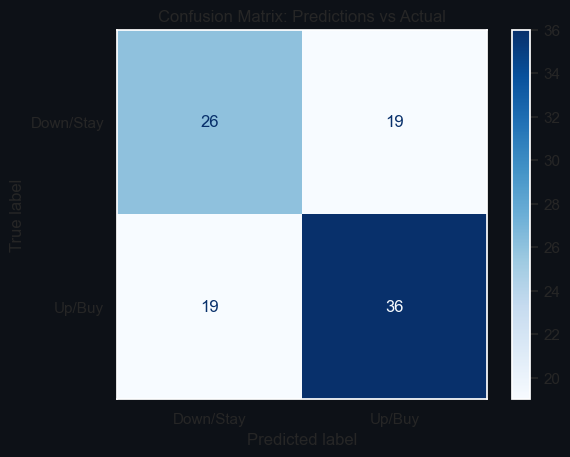

In [337]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the matrix
cm = confusion_matrix(combined['Target'], combined['Model Predection'])

# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Stay', 'Up/Buy'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Predictions vs Actual')
plt.show()

In [338]:
# create function that fit the model and combine the target column with prediction column

def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    merged = pd.concat([test["Target"], preds], axis=1)

    return merged


In [339]:
predictions = predict(train, test, predictors, model)

In [340]:
predictions

,Target,Predictions
Date,,
2025-11-21,1,1
2025-11-24,1,1
2025-11-25,1,1
2025-11-26,1,1
2025-11-28,0,0
...,...,...
2026-04-13,1,1
2026-04-14,1,0
2026-04-15,1,0


In [341]:
accuracy_score(predictions["Target"], predictions["Predictions"])

0.62

In [342]:
precision_score(predictions["Target"], predictions["Predictions"])

0.6545454545454545

In [343]:
recall_score(predictions["Target"], predictions["Predictions"])

0.6545454545454545

In [344]:
f1_score(predictions["Target"], predictions["Predictions"])

0.6545454545454545

In [345]:
confusion_matrix(predictions["Target"], predictions["Predictions"])

array([[26, 19],
       [19, 36]])

## ADDING ADDITIONAL PREDICTORS TO OUR MODEL
(Feature Engineering)

In [346]:
# 2 day , 1 week, 3 motns, 1 year, 4 year
horizens = [2, 5, 60, 250, 1000]

new_predictores = []

for horizon in horizens:
    rolling_avgs = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_avgs["Close"]

    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]
   
    new_predictores += [ratio_column, trend_column]


In [347]:
sp500 = sp500.dropna()

In [348]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-10,6839.240234,6845.770020,6808.459961,6816.890137,4393220000,6886.240234,1,0.999430,1.0,1.012819,4.0,1.004162,29.0,1.051499,144.0,1.319204,536.0
2026-04-13,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,6967.379883,1,1.005061,1.0,1.014848,4.0,1.014478,30.0,1.061199,144.0,1.331982,537.0
2026-04-14,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195,1,1.005857,2.0,1.016305,4.0,1.026374,30.0,1.072670,144.0,1.347006,538.0


# Summary statistics

In [349]:
sp500.describe()

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
count,8139.000000,8139.000000,8139.000000,8139.000000,8.139000e+03,8139.000000,8139.000000,8139.000000,8139.00000,8139.000000,8139.000000,8139.000000,8139.000000,8139.000000,8139.000000,8139.000000,8139.000000
mean,2037.339603,2049.049572,2024.803739,2037.754898,2.891327e+09,2038.573549,0.539993,1.000167,1.07974,1.000689,2.698612,1.010166,32.389606,1.043860,134.816439,1.177864,536.903919
std,1496.059940,1503.211750,1488.291240,1496.302552,1.792028e+09,1497.263314,0.498429,0.005861,0.69149,0.012017,1.060570,0.042525,3.818659,0.089880,9.676785,0.200709,21.562676
min,439.140015,444.720001,435.859985,438.920013,0.000000e+00,438.920013,0.000000,0.936260,0.00000,0.897275,0.000000,0.717536,21.000000,0.586920,107.000000,0.525568,472.000000
25%,1100.535034,1107.210022,1093.710022,1100.725037,1.227650e+09,1100.850037,0.000000,0.997738,1.00000,0.995067,2.000000,0.991513,30.000000,1.003620,129.000000,1.087903,528.000000
50%,1375.969971,1386.660034,1365.060059,1375.939941,3.210950e+09,1376.510010,1.000000,1.000336,1.00000,1.001721,3.000000,1.017058,33.000000,1.060265,137.000000,1.194077,540.000000
75%,2645.460083,2665.319946,2625.079956,2643.010010,4.072795e+09,2643.770020,1.000000,1.002912,2.00000,1.007171,3.000000,1.036937,35.000000,1.103229,142.000000,1.309501,553.000000
max,7037.779785,7051.229980,7008.520020,7041.279785,1.145623e+10,7126.060059,1.000000,1.054731,2.00000,1.087230,5.000000,1.158054,43.000000,1.233412,157.000000,1.664084,572.000000


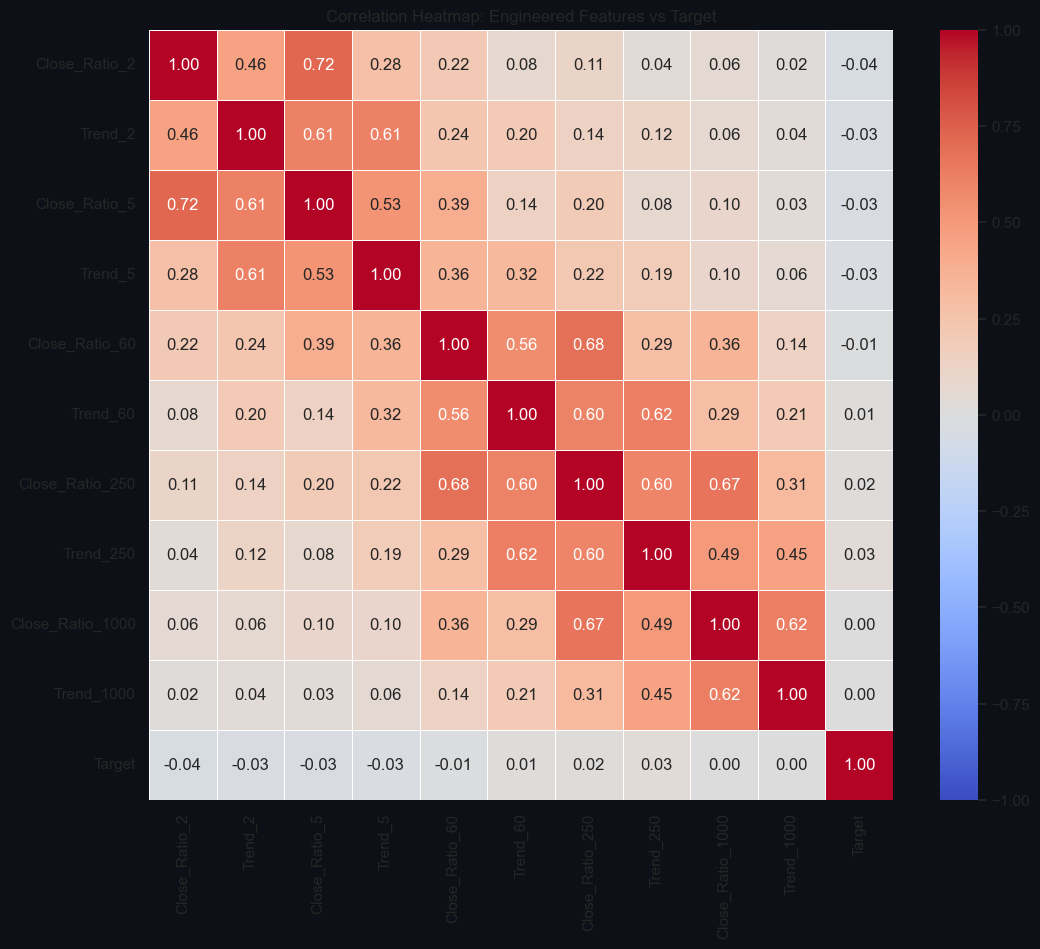

In [350]:

# 1. تحديد القائمة بالميزات الجديدة التي أنشأتها فقط + الهدف
# نستخدم list comprehension للبحث عن الأعمدة التي تحتوي على كلمات Trend أو Ratio
engineered_features = [col for col in sp500.columns if 'Trend' in col or 'Ratio' in col]
columns_to_analyze = engineered_features + ['Target']

# 2. حساب مصفوفة الارتباط
corr_matrix = sp500[columns_to_analyze].corr()

# 3. إعداد الرسم البياني
plt.figure(figsize=(12, 10))

# 4. رسم الخريطة الحرارية (Heatmap)
sns.heatmap(corr_matrix, 
            annot=True,            # إظهار الأرقام داخل المربعات
            fmt=".2f",             # تقريب الأرقام لخانين عشريتين
            cmap='coolwarm',       # لون أزرق للارتباط السالب وأحمر للموجب
            linewidths=0.5,        # إضافة فواصل بسيطة بين المربعات
            vmin=-1, vmax=1)       # تحديد نطاق الألوان من -1 إلى 1

plt.title('Correlation Heatmap: Engineered Features vs Target')
plt.show()

## IMPROVING OUR MODEL

In [351]:
# we change the parameters
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [352]:
def predict(train, test, new_predictores, model):

    model.fit(train[new_predictores], train["Target"])
    preds = model.predict_proba(test[new_predictores])[:,1]

    # modify the threshold
    preds[preds >= 0.6] = 1
    preds[preds < 0.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    merged = pd.concat([test["Target"], preds], axis=1)

    return merged

In [353]:
# The function systematically moves through your dataset in chunks, training the model on all 
# data available up to a certain point and then testing it on the next immediate block of data.

# Because data from the past is not the same as data from the present; it is constantly changing.

# each 250 row represnts a one trading year 

# we train the model in the first 10 years and test it in the 11th year the train it in 11th year and test it in 12th year and so on....


def backtest(data, new_predictores, model, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):

        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()

        predictions = predict(train, test, new_predictores, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)

In [354]:
predictions = backtest(sp500, new_predictores, model)

In [355]:
predictions.shape[0]

5639

In [356]:
accuracy_score(predictions["Target"], predictions["Predictions"])

0.47561624401489627

In [357]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5722411831626849

In [358]:
recall_score(predictions["Target"], predictions["Predictions"])

0.16309987029831388

In [359]:
f1_score(predictions["Target"], predictions["Predictions"])

0.25384809487761795

In [360]:
confusion_matrix(predictions["Target"], predictions["Predictions"])

array([[2179,  376],
       [2581,  503]])

In [361]:
preds

,Model Predection
Date,
2025-11-21,1
2025-11-24,1
2025-11-25,1
2025-11-26,1
2025-11-28,0
...,...
2026-04-13,1
2026-04-14,0
2026-04-15,0


In [362]:
preds = predictions

def precision_fig(preds):
    # 1. Filter and count
    buy_signals = preds[preds["Predictions"] == 1]
    counts = buy_signals["Target"].value_counts().sort_index()
    
    categories = ['Wrong (Price went Down)', 'Right (Price went Up)']
    values = [counts.get(0, 0), counts.get(1, 0)]

    # 2. Setup Theme & Layout
    sns.set_theme(style="dark", rc={
        "axes.facecolor": "#0d1117", 
        "figure.facecolor": "#0d1117",
        "grid.color": "#21262d"
    })
    plt.figure(figsize=(10, 6))
    
    # 3. Create the Plot (Fixed for v0.14.0 compatibility)
    ax = sns.barplot(
        x=categories, 
        y=values, 
        hue=categories, 
        legend=False, 
        palette=['#ef553b', '#00cc96']
    )

    # 4. ADD LABELS TO BOTH BARS
    # ax.containers[0] captures both the red and green bar objects
    ax.bar_label(ax.containers[0], color='white', padding=5, fontsize=12, weight='bold')

    # 5. Styling & Spacing
    plt.title("Outcome of 'Price Up' Predictions", color='white', weight='bold', loc='left', pad=25)
    plt.ylabel("Number of Days", color='white')
    
    # CRITICAL: Increase Y-limit so the labels don't hit the top of the box
    plt.ylim(0, max(values) * 1.15) 
    
    plt.xticks(color='white')
    plt.yticks(color='white')
    
    # Remove the box border for a cleaner "Plotly" look
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.show()


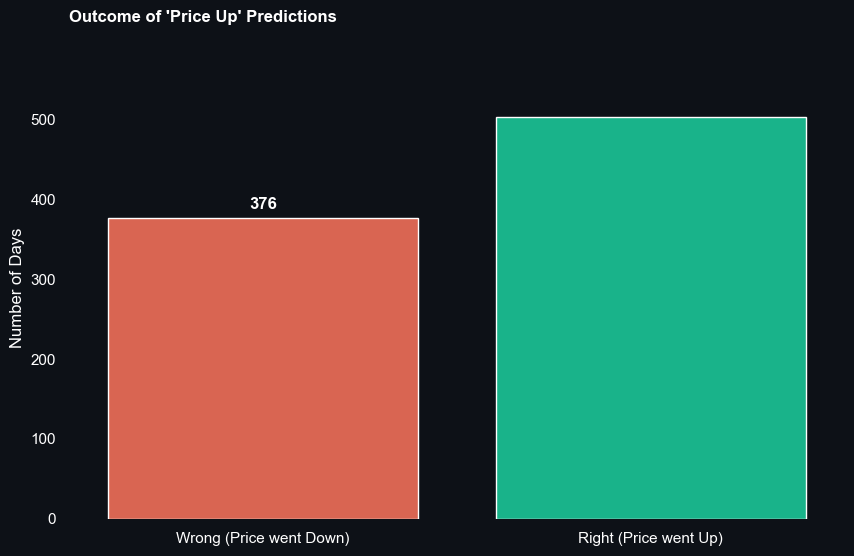

In [363]:
precision_fig(preds)

In [364]:
import xgboost as xgb

In [365]:
xgbc = xgb.XGBClassifier(n_estimators=200, min_child_weight=50, random_state=1)
model = xgbc

In [366]:
preds = backtest(sp500, new_predictores, model)

In [367]:
accuracy_score(preds["Target"], preds["Predictions"])

0.4944139031743217

In [368]:
precision_score(preds["Target"], preds["Predictions"])

0.5573609059576563

In [369]:
recall_score(preds["Target"], preds["Predictions"])

0.3670557717250324

In [370]:
f1_score(preds["Target"], preds["Predictions"])

0.4426197458455523

In [371]:
confusion_matrix(preds["Target"], preds["Predictions"])

array([[1656,  899],
       [1952, 1132]])

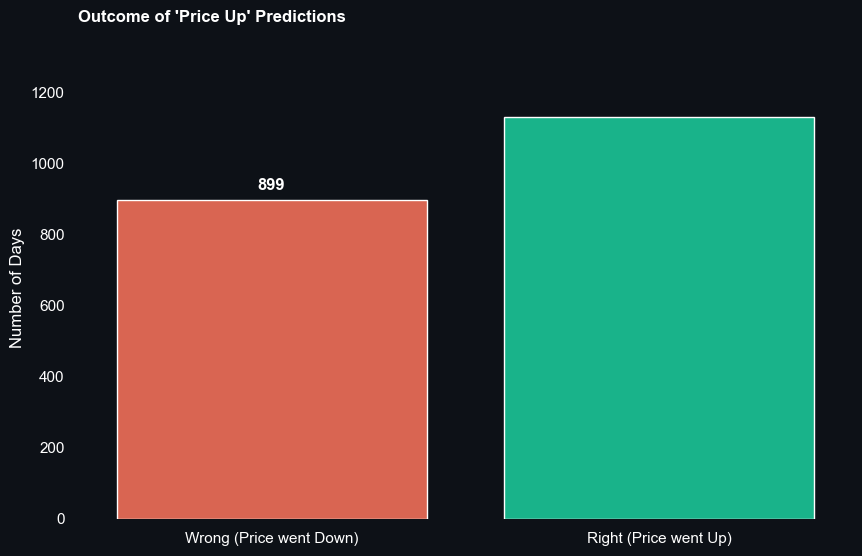

In [372]:
precision_fig(preds)

In [373]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# n_neighbors=10 looks at the 10 most similar historical days
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=10)
)

In [374]:
preds = backtest(sp500, new_predictores, model)

In [375]:
preds

,Target,Predictions
Date,,
2003-11-14,0,1.0
2003-11-17,0,1.0
2003-11-18,1,1.0
2003-11-19,0,0.0
2003-11-20,1,0.0
...,...,...
2026-04-10,1,1.0
2026-04-13,1,1.0
2026-04-14,1,0.0


In [376]:
accuracy_score(preds["Target"], preds["Predictions"])

0.4977832949104451

In [377]:
precision_score(preds["Target"], preds["Predictions"])

0.5486111111111112

In [378]:
recall_score(preds["Target"], preds["Predictions"])

0.46108949416342415

In [379]:
f1_score(preds["Target"], preds["Predictions"])

0.5010570824524313

In [380]:
confusion_matrix(preds["Target"], preds["Predictions"])

array([[1385, 1170],
       [1662, 1422]])

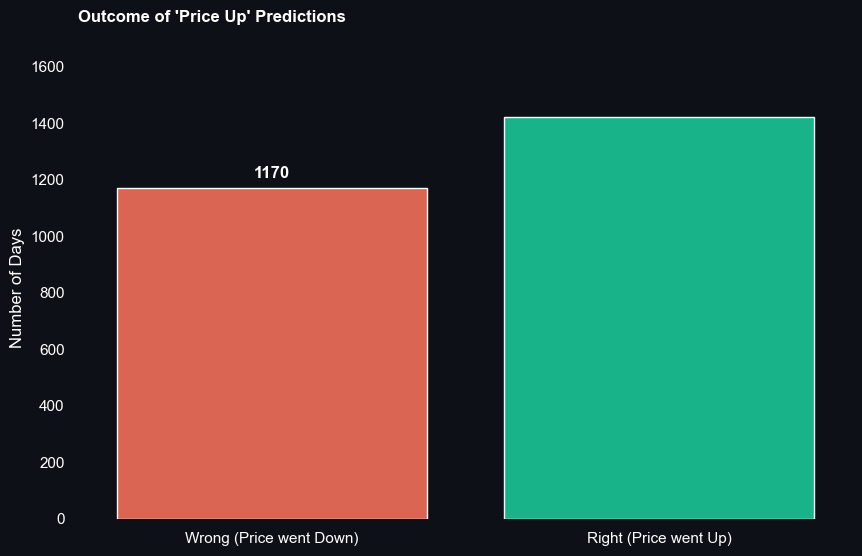

In [381]:
precision_fig(preds)